# Example with **DeCo**

>Tutorial author:Chenxi Wang（<sunnywcx@zju.deu.cn>）

In this tutorial, we use `LLaVA-1.5-7b` generate an image caption `DeCo`, we hope this tutorial could help you understand how to use the method DeCo on MLLMs, using the DeCo method with the LLaVA-1.5-7b as an example.

Model Hyparameters Config

In [1]:
device = "cuda"
conv_mode = "llava_v1"
model_path = "/data1/zhr/checkpoints/llava-v1.5-7b"
image_file = "/data1/zhr/datasets/val2014/COCO_val2014_000000175440.jpg"
qs = "Please describe this image in detail."
temperature = -1
top_p = None
num_beams = 1
max_new_tokens = 512

#hyparams
use_deco = True
alpha = 0.5
threshold_top_p = 0.9
threshold_top_k = 20
early_exit_layers=[i for i in range(20, 29, 1)]

In [2]:
import argparse
import torch
import torch.nn.functional as F
import os
import json
from tqdm import tqdm
import shortuuid
import sys
import os
import random
import numpy as np
os.environ["CUDA_VISIBLE_DEVICES"] = "2"
from llava.constants import (
    IMAGE_TOKEN_INDEX,
    DEFAULT_IMAGE_TOKEN,
    DEFAULT_IM_START_TOKEN,
    DEFAULT_IM_END_TOKEN,
)
from llava.conversation import conv_templates, SeparatorStyle
from llava.model.builder import load_pretrained_model
from llava.mm_utils import tokenizer_image_token, get_model_name_from_path, KeywordsStoppingCriteria
from PIL import Image
import requests
from io import BytesIO
import matplotlib.pyplot as plt
import torch.backends.cudnn as cudnn
from llava.utils import disable_torch_init

/home/zhr/.conda/envs/deco/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
def load_image(image_file):
    if image_file.startswith("http") or image_file.startswith("https"):
        response = requests.get(image_file)
        image = Image.open(BytesIO(response.content)).convert("RGB")
    else:
        image = Image.open(image_file).convert("RGB")
    return image

def load_images(image_files):
    out = []
    for image_file in image_files:
        image = load_image(image_file)
        out.append(image)
    return out

def setup_seeds():
    seed = 927

    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    cudnn.benchmark = False
    cudnn.deterministic = True

load model

In [4]:
setup_seeds()

disable_torch_init()

model_name = get_model_name_from_path(model_path)
tokenizer, model, image_processor, context_len = load_pretrained_model(model_path=model_path, 
                                                                       model_base=None, 
                                                                       model_name=model_name, 
                                                                       device=device,
                                                                       device_map=device)

/home/zhr/.conda/envs/deco/lib/python3.9/site-packages/huggingface_hub/file_download.py:1142: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]/home/zhr/DeCo_JSD/transformers/modeling_utils.py:460: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they 

In [5]:
# image_file = "/home/zhr/Deco/test.png"
image_id = 226988
image_file = "/data1/zhr/datasets/coco2014/val2014/" + "COCO_val2014_"+str(image_id).zfill(12) + ".jpg"
qs = "Please describe this image in detail."
if model.config.mm_use_im_start_end:
    qs = DEFAULT_IM_START_TOKEN + DEFAULT_IMAGE_TOKEN + DEFAULT_IM_END_TOKEN + '\n' + qs
else:
    qs = DEFAULT_IMAGE_TOKEN + '\n' + qs

conv = conv_templates[conv_mode].copy()
conv.append_message(conv.roles[0], qs)
conv.append_message(conv.roles[1], None)
prompt = conv.get_prompt()

input_ids = tokenizer_image_token(prompt, tokenizer, IMAGE_TOKEN_INDEX, return_tensors='pt').unsqueeze(0).to(device)

image = Image.open(image_file)
image_tensor = image_processor.preprocess(image, return_tensors='pt')['pixel_values'][0]
                
stop_str = conv.sep if conv.sep_style != SeparatorStyle.TWO else conv.sep2
keywords = [stop_str]
stopping_criteria = KeywordsStoppingCriteria(keywords, tokenizer, input_ids)


In [6]:
# with torch.inference_mode():
#     with torch.no_grad():
#         ori_output_dict = model.generate(
#             input_ids,
#             images=image_tensor.unsqueeze(0).half().to(device),
#             do_sample=True if temperature > 0 else False,
#             temperature=temperature,
#             top_p=top_p,
#             num_beams=num_beams,
#             max_new_tokens=max_new_tokens,
#             # return_dict=True,
#             # return_dict_in_generate=True,
#             # output_hidden_states=True,
#             stopping_criteria=[stopping_criteria],
#         )

# output_ids = ori_output_dict
# input_token_len = input_ids.shape[1]
# outputs = tokenizer.batch_decode(
#         output_ids[:, input_token_len:], skip_special_tokens=True
#     )[0]
# ori_outputs = outputs.strip()

In [7]:
# with torch.inference_mode():
#     with torch.no_grad():
#         deco_output_dict = model.generate(
#             input_ids,
#             images=image_tensor.unsqueeze(0).half().to(device),
#             do_sample=True if temperature > 0 else False,
#             temperature=temperature,
#             top_p=top_p,
#             num_beams=num_beams,
#             max_new_tokens=max_new_tokens,
#             return_dict=True,
#             # return_dict_in_generate=True,
#             output_hidden_states=True,
#             stopping_criteria=[stopping_criteria],
#             use_deco = True,
#             alpha=alpha,
#             threshold_top_p=threshold_top_p,
#             threshold_top_k=threshold_top_k,
#             early_exit_layers=early_exit_layers,
#         )
        
# output_ids = deco_output_dict
# input_token_len = input_ids.shape[1]
# outputs = tokenizer.batch_decode(
#         output_ids[:, input_token_len:], skip_special_tokens=True
#     )[0]
# deco_outputs = outputs.strip()

In [8]:

with torch.inference_mode():
    with torch.no_grad():
        output_dict, uncond_output_dict = model.generate(
            input_ids,
            images=image_tensor.unsqueeze(0).half().to(device),
            do_sample=True if temperature > 0 else False,
            temperature=temperature,
            top_p=top_p,
            num_beams=num_beams,
            max_new_tokens=max_new_tokens,
            return_dict=True,
            return_dict_in_generate=True,
            output_hidden_states=True,
            output_scores=True,
            stopping_criteria=[stopping_criteria],
            use_jsd = True,
            alpha=alpha,
            threshold_top_p=threshold_top_p,
            threshold_top_k=threshold_top_k,
            early_exit_layers=early_exit_layers,
        )

output_ids = output_dict.sequences
input_token_len = input_ids.shape[1]
outputs = tokenizer.batch_decode(
        output_ids[:, input_token_len:], skip_special_tokens=True
    )[0]
outputs = outputs.strip()

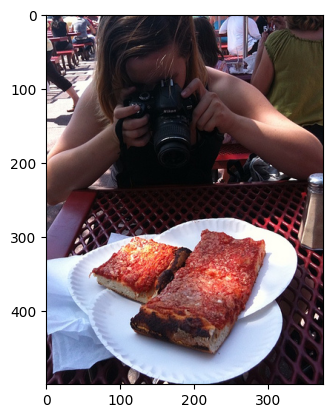

Ours:
 The image features a woman sitting at a red dining table, taking a picture of two slices of pizza using her camera. The pizza slices are placed on a white plate, and she is capturing the delicious meal in a close-up shot.

There are other people in the scene, with one person standing near the table and a couple of others in the background. A bench is visible in the background, and a chair is placed nearby. Additionally, there are a few backpacks and handbags scattered around the table, indicating that the people might be in a public eating area. A bottle is also present on the table, possibly containing a beverage to accompany the pizza.


In [9]:
plt.imshow(image)
plt.show()
# print("Original:\n", ori_outputs)
# print("\n")
# print("DeCo:\n", deco_outputs)
# print("\n")
print("Ours:\n", outputs)

In [18]:
start_idx = 83
outputs_tokens = output_ids[0, input_token_len:]
words = tokenizer.decode(outputs_tokens[start_idx:]).encode("unicode_escape").decode()
print("len:", len(outputs_tokens))
print(words)

len: 152
 bench is visible in the background, and a chair is placed nearby. Additionally, there are a few backpacks and handbags scattered around the table, indicating that the people might be in a public eating area. A bottle is also present on the table, possibly containing a beverage to accompany the pizza.</s>


In [20]:
# token_idx = -68
# token_idx = -63
# token_idx = -42
token_idx = 83
threshold_top_k = 10
layer_logits = []
uncond_layer_logits = []

hidden_states = output_dict.hidden_states[token_idx]
uncond_hidden_states = uncond_output_dict.hidden_states[token_idx]

for layer_id in range(0, 33):
    if layer_id != 32:
        layer_output = model.model.norm(hidden_states[layer_id])
        uncond_layer_output = model.model.norm(uncond_hidden_states[layer_id])
    else:
        layer_output = hidden_states[layer_id].clone()
        uncond_layer_output = uncond_hidden_states[layer_id].clone()
    logits = model.lm_head(layer_output)[:,-1,:]
    uncond_logits = model.lm_head(uncond_layer_output)[:,-1,:]
    layer_logits.append(logits)
    uncond_layer_logits.append(uncond_logits)

stacked_layer_logits = torch.stack(layer_logits, dim=0) # shape: (num_layers, batch_size, vocab_size)
stacked_uncond_layer_logits = torch.stack(uncond_layer_logits, dim=0)

layer_softmax = F.softmax(stacked_layer_logits, dim=-1) # shape: (num_layers, batch_size, vocab_size)
uncond_layer_softmax = F.softmax(stacked_uncond_layer_logits, dim=-1)

layer_log_softmax = F.log_softmax(stacked_layer_logits, dim=-1)
uncond_layer_log_softmax =F.log_softmax(stacked_uncond_layer_logits, dim=-1)

final_layer_softmax = layer_softmax[-1, :, :]
final_layer_log_softmax = layer_log_softmax[-1, :, :]

In [21]:
probs = layer_softmax.squeeze()
uncond_probs = uncond_layer_softmax.squeeze()
# probs = layer_log_softmax.squeeze()
# uncond_probs = uncond_layer_log_softmax.squeeze()

candidate_tokens_probs, candidate_tokens_ids = torch.topk(probs[-1], dim=-1, k=threshold_top_k)

candidate_tokens_cumulative_probs = candidate_tokens_probs.cumsum(dim=-1)
candidate_tokens_indices = torch.searchsorted(candidate_tokens_cumulative_probs, threshold_top_p, right=False)
candidate_tokens_cutoff_idx = torch.min(candidate_tokens_indices + 1, torch.tensor(threshold_top_k))   

candidate_tokens_ids = candidate_tokens_ids[:candidate_tokens_cutoff_idx]

candidate_tokens_early_exit_probs = probs[:,candidate_tokens_ids]
uncond_candidate_tokens_early_exit_probs = uncond_probs[:,candidate_tokens_ids]

words = [tokenizer.decode(t.cpu()).encode("unicode_escape").decode() for t in candidate_tokens_ids]

final_softmax_score = F.softmax(output_dict.scores[token_idx][0], dim=-1)
final_tokens_probs, final_tokens_ids = torch.topk(final_softmax_score, dim=-1, k=threshold_top_k)

final_words = [tokenizer.decode(t.cpu()).encode("unicode_escape").decode() for t in final_tokens_ids]

print("top_p_candidate_tokens\n", words)
print(candidate_tokens_probs[:candidate_tokens_cutoff_idx])

print("final_tokens\n", final_words)
print(final_tokens_probs)

top_p_candidate_tokens
 ['chair', 'ben', 'back', 'hand', 'couple', 'bott', 'few']
tensor([0.3076, 0.2847, 0.1431, 0.0578, 0.0487, 0.0423, 0.0291],
       device='cuda:0', dtype=torch.float16, grad_fn=<SliceBackward0>)
final_tokens
 ['ben', 'chair', 'back', 'hand', 'bott', 'couple', 'few', '</s>', '<s>', '<unk>']
tensor([0.5548, 0.2143, 0.1365, 0.0324, 0.0266, 0.0210, 0.0145, 0.0000, 0.0000,
        0.0000], device='cuda:0')


In [22]:
# cross layer JSD
M = 0.5 * (layer_softmax[...,candidate_tokens_ids] + uncond_layer_softmax[...,candidate_tokens_ids])

kl1 = F.kl_div(layer_log_softmax[...,candidate_tokens_ids], M, reduction='none').mean(-1) # shape: (num_layers, batch_size)
kl2 = F.kl_div(uncond_layer_log_softmax[...,candidate_tokens_ids], M, reduction='none').mean(-1)
js_divs = 0.5 * (kl1 + kl2)
cross_layer_js_divs = js_divs.mean(-1) # shape: (num_layers,)

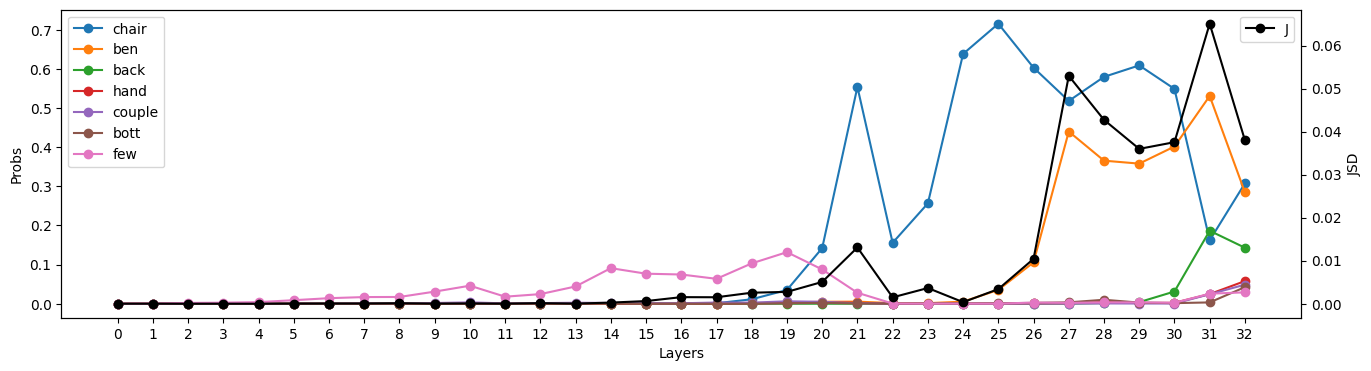

Max JS divergence idx:  31


In [23]:
fig, ax = plt.subplots(figsize=(16, 4))

ax.plot(candidate_tokens_early_exit_probs.detach().cpu().numpy(), marker = 'o')
ax.set_xlabel("Layers")
ax.set_ylabel("Probs")
ax.set_xticks(range(33))
# ax.set_ylim(0, 1)
ax.legend(words, loc='upper left')

# jsd = cross_layer_js_divs.max() - cross_layer_js_divs
jsd = cross_layer_js_divs

ax2 = ax.twinx()
ax2.plot(jsd.detach().cpu().numpy(), marker = 'o', color = 'black')
ax2.set_ylabel("JSD")
ax2.legend("J")

plt.show()
print("Max JS divergence idx: ", jsd.argmax().item())

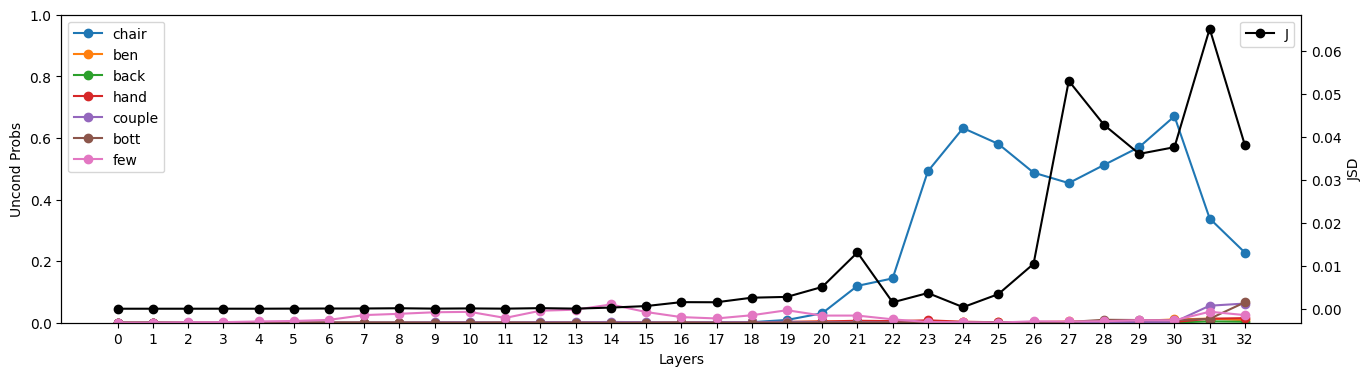

In [24]:
fig, ax = plt.subplots(figsize=(16, 4))

ax.plot(uncond_candidate_tokens_early_exit_probs.detach().cpu().numpy(), marker = 'o')
ax.set_xlabel("Layers")
ax.set_ylabel("Uncond Probs")
ax.set_xticks(range(33))
ax.set_ylim(0, 1)
ax.legend(words, loc='upper left')

# jsd = cross_layer_js_divs.max() - cross_layer_js_divs
jsd = cross_layer_js_divs

ax2 = ax.twinx()
ax2.plot(jsd.detach().cpu().numpy(), marker = 'o', color = 'black')
ax2.set_ylabel("JSD")
ax2.legend("J")

plt.show()